AttributeError: 'Text' object has no property 'kwargs_labels'

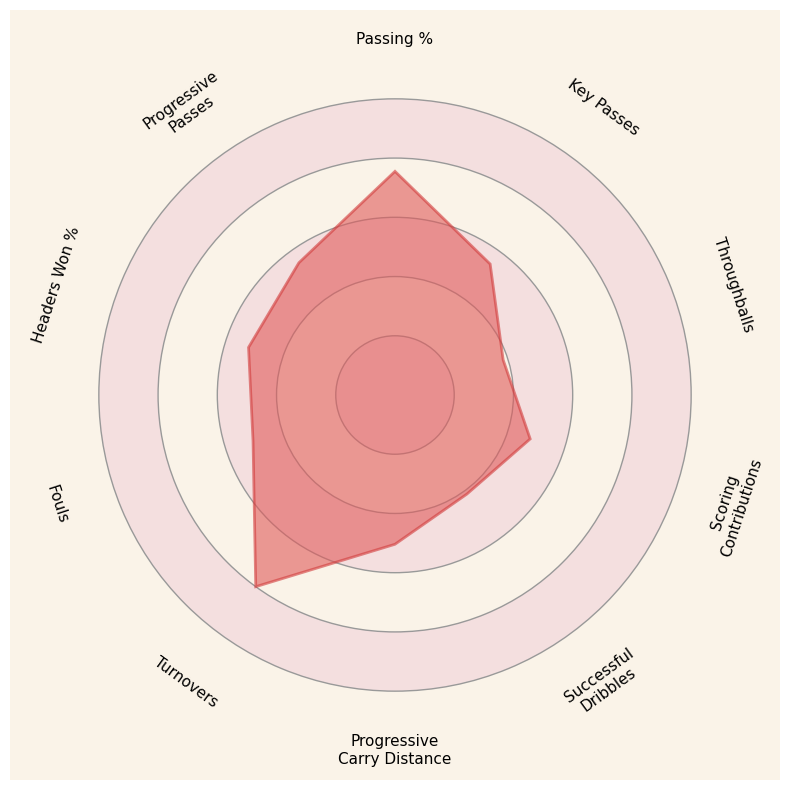

In [1]:
import matplotlib.pyplot as plt
from mplsoccer import Radar

# 1. Define the metrics and their respective scales (Lower and Upper bounds)
# You must define the min and max for EACH axis because they are not on the same scale.
params = [
    'Passing %', 'Key Passes', 'Throughballs', 'Scoring Contributions',
    'Successful Dribbles', 'Progressive Carry Distance', 'Turnovers', 
    'Fouls', 'Headers Won %', 'Progressive Passes'
]

# Define the lower and upper limits for the radar axes
lower_bounds = [50, 0.0, 0.0, 0.0, 0.0, 0, 0.0, 0.0, 0.0, 0.0]
upper_bounds = [100, 3.0, 1.0, 1.0, 3.0, 150, 10.0, 5.0, 100, 10.0]

# 2. Input the player data
# Richard Rios (Red)
rios_data = [84.7, 1.3, 0.23, 0.35, 0.8, 57.0, 7.5, 1.9, 40.0, 4.4]
# Neil El Aynaoui (Yellow)
el_aynaoui_data = [81.7, 1.0, 0.28, 0.28, 0.8, 68.0, 7.8, 2.8, 42.9, 4.1]

# 3. Initialize the Radar object
radar = Radar(
    params, lower_bounds, upper_bounds,
    round_int=[False]*len(params), # Set to True if you want integers on labels
    num_rings=4,  # The number of concentric circles
    ring_width=1, center_circle_radius=1
)

# 4. Set up the figure and axis
fig, ax = radar.setup_axis(facecolor='#FAF3E8') # Matching the off-white background
fig.set_size_inches(10, 10)

# 5. Draw the background rings and labels
# Draw concentric rings
rings_inner = radar.draw_circles(ax=ax, facecolor='#f4dfdf', edgecolor='#999999')
# Draw the parameter labels around the edge
axis_labels = radar.draw_param_labels(ax=ax, fontsize=11, color='black')

# 6. Plot Player 1 (Richard Rios - Red)
radar1, vertices1 = radar.draw_radar_solid(
    rios_data, ax=ax, 
    kwargs={'facecolor': '#e05a5a', 'alpha': 0.6, 'edgecolor': '#d13a3a', 'lw': 2}
)
# Add floating data labels for Player 1
labels1 = radar.draw_range_labels(
    ax=ax, offset=0, 
    kwargs_labels={'color': '#d13a3a', 'fontsize': 10, 'weight': 'bold'}
)

# 7. Plot Player 2 (Neil El Aynaoui - Yellow)
radar2, vertices2 = radar.draw_radar_solid(
    el_aynaoui_data, ax=ax, 
    kwargs={'facecolor': '#f2d16b', 'alpha': 0.6, 'edgecolor': '#d6b245', 'lw': 2}
)
# Add floating data labels for Player 2
labels2 = radar.draw_range_labels(
    ax=ax, offset=0.5, # Offset slightly so they don't overlap perfectly
    kwargs_labels={'color': '#d6b245', 'fontsize': 10, 'weight': 'bold'}
)

# Optional: Add a central image/color (the soccer ball in your image)
center = ax.scatter([0], [0], s=3000, c='black', zorder=10)

plt.show()

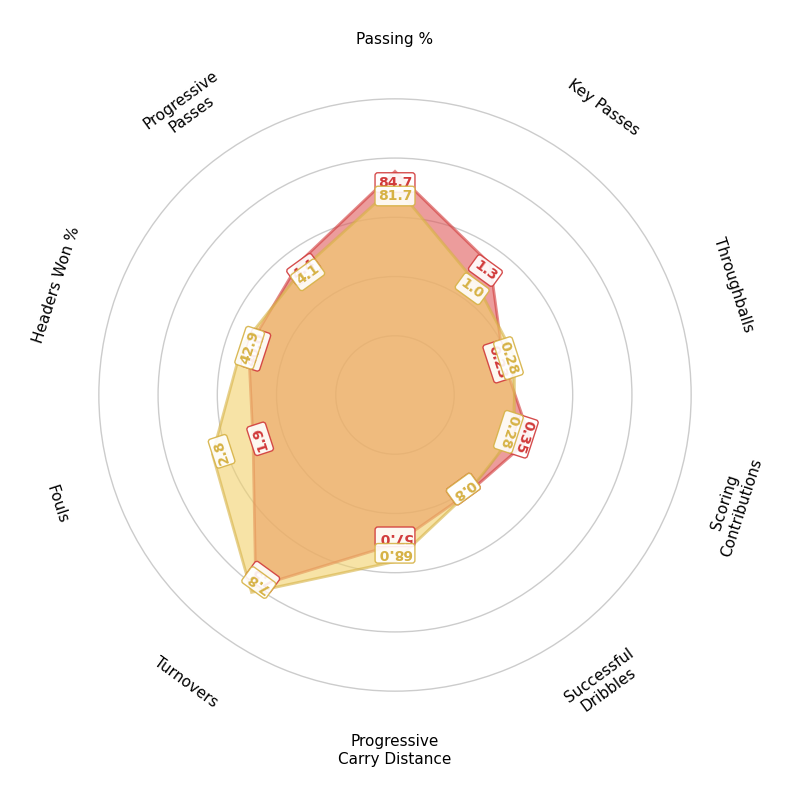

In [2]:
import matplotlib.pyplot as plt
from mplsoccer import Radar

# 1. Define the metrics and scales
params = [
    'Passing %', 'Key Passes', 'Throughballs', 'Scoring Contributions',
    'Successful Dribbles', 'Progressive Carry Distance', 'Turnovers', 
    'Fouls', 'Headers Won %', 'Progressive Passes'
]

lower_bounds = [50, 0.0, 0.0, 0.0, 0.0, 0, 0.0, 0.0, 0.0, 0.0]
upper_bounds = [100, 3.0, 1.0, 1.0, 3.0, 150, 10.0, 5.0, 100, 10.0]

# 2. Input the player data
rios_data = [84.7, 1.3, 0.23, 0.35, 0.8, 57.0, 7.5, 1.9, 40.0, 4.4]
el_aynaoui_data = [81.7, 1.0, 0.28, 0.28, 0.8, 68.0, 7.8, 2.8, 42.9, 4.1]

# 3. Initialize the Radar object
radar = Radar(
    params, lower_bounds, upper_bounds,
    round_int=[False]*len(params),
    num_rings=4, 
    ring_width=1, center_circle_radius=1
)

# 4. Set up a pure white figure and axis
fig, ax = radar.setup_axis(facecolor='white') 
fig.set_size_inches(10, 10)

# 5. Draw transparent background rings and labels
# facecolor='none' ensures no extra colors are filled in
rings_inner = radar.draw_circles(ax=ax, facecolor='none', edgecolor='#CCCCCC', lw=1)
axis_labels = radar.draw_param_labels(ax=ax, fontsize=11, color='black')

import numpy as np

# Set how far inward you want the labels 
pull_factor = 0.95

# 6. Plot Player 1 (Richard Rios - Red)
radar1, vertices1 = radar.draw_radar_solid(
    rios_data, ax=ax, 
    kwargs={'facecolor': '#e05a5a', 'alpha': 0.6, 'edgecolor': '#d13a3a', 'lw': 2}
)

# Add floating, rotated data labels for Player 1
for i, val in enumerate(rios_data):
    x = vertices1[i, 0] * pull_factor
    y = vertices1[i, 1] * pull_factor
    
    # Calculate the angle of the point from the center
    angle_deg = np.degrees(np.arctan2(y, x))
    
    # Subtract 90 degrees so the bottom of the text faces the center
    rotation_angle = angle_deg - 90
    
    ax.text(
        x, y, f'{val}',
        ha='center', va='center', rotation=rotation_angle,
        color='#d13a3a', fontsize=10, weight='bold',
        bbox=dict(facecolor='white', edgecolor='#d13a3a', boxstyle='round,pad=0.2', alpha=0.9)
    )

# 7. Plot Player 2 (Neil El Aynaoui - Yellow)
radar2, vertices2 = radar.draw_radar_solid(
    el_aynaoui_data, ax=ax, 
    kwargs={'facecolor': '#f2d16b', 'alpha': 0.6, 'edgecolor': '#d6b245', 'lw': 2}
)

# Add floating, rotated data labels for Player 2
for i, val in enumerate(el_aynaoui_data):
    x = vertices2[i, 0] * pull_factor
    y = vertices2[i, 1] * pull_factor
    
    # Calculate the angle of the point from the center
    angle_deg = np.degrees(np.arctan2(y, x))
    
    # Subtract 90 degrees so the bottom of the text faces the center
    rotation_angle = angle_deg - 90
    
    ax.text(
        x, y, f'{val}',
        ha='center', va='center', rotation=rotation_angle,
        color='#d6b245', fontsize=10, weight='bold',
        bbox=dict(facecolor='white', edgecolor='#d6b245', boxstyle='round,pad=0.2', alpha=0.9)
    )

plt.show()